# Regresión Lineal para explicar el Puntaje Global de Saber 11° 2020-1

**Curso:** Machine Learning / Esp. Analítica y Ciencia de Datos  
**Autor:** David Alonso Torres Rivas  
**Fuente:** Datos Abiertos Colombia – ICFES  
**Dataset:** Saber 11° 2020-1 (`a8xr-en99`)

## Objetivo

Construir un modelo de Regresión Lineal para estimar el `punt_global` a partir de cuatro características categóricas:

- `fami_estratovivienda`
- `fami_personashogar`
- `estu_genero`
- `cole_naturaleza`

El análisis busca identificar asociaciones útiles para la predicción, no establecer relaciones causales.

## 1. Importación de librerías y configuración

Se utiliza una semilla fija para facilitar la reproducibilidad de la partición entrenamiento/prueba.

In [3]:
!pip install scikit-learn

  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 6.1 MB/s  0:00:01m0:00:0100:01
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
Using cached threadpoolctl-3.7.0-py3-none-any.whl (26 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]


In [7]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 6.5 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [statsmodels] [statsmodels]


In [14]:
import warnings
warnings.filterwarnings("ignore")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
print("librerías cargadas")

librerías cargadas


## 2. Recolección de datos

El conjunto de datos procede del portal oficial Datos Abiertos Colombia y corresponde a los resultados de Saber 11° 2020-1.

La API Socrata permite consultar el conjunto mediante el identificador `a8xr-en99`.

**Endpoint:** `https://www.datos.gov.co/resource/a8xr-en99.json`

Para mantener la trazabilidad, el código intenta descargar los datos directamente desde la API. Como respaldo para trabajar sin conexión, también permite utilizar el CSV guardado en `data/`.

In [15]:
from pathlib import Path

API_URL = "https://www.datos.gov.co/resource/a8xr-en99.json?$limit=50000"
LOCAL_FILE = Path("../data/Saber_11_2020-1.csv")

try:
    df = pd.read_json(API_URL)
    print("Datos cargados desde la API:", df.shape)
except Exception as e:
    print("No fue posible consultar la API. Se intentará usar el archivo local.")
    print("Detalle:", e)
    df = pd.read_csv(LOCAL_FILE, low_memory=False)
    print("Datos cargados desde archivo local:", df.shape)

Datos cargados desde la API: (15435, 78)


### 2.1 Revisión inicial

In [16]:
print("Dimensiones:", df.shape)
display(df.head())
display(df.dtypes.to_frame("tipo").head(20))

Dimensiones: (15435, 78)


,estu_tipodocumento,estu_nacionalidad,estu_genero,estu_fechanacimiento,periodo,estu_consecutivo,estu_estudiante,estu_pais_reside,estu_tieneetnia,estu_depto_reside,estu_cod_reside_depto,estu_mcpio_reside,estu_cod_reside_mcpio,fami_estratovivienda,fami_personashogar,fami_cuartoshogar,fami_educacionpadre,fami_educacionmadre,fami_trabajolaborpadre,fami_trabajolabormadre,fami_tieneinternet,fami_tieneserviciotv,fami_tienecomputador,fami_tienelavadora,fami_tienehornomicroogas,fami_tieneautomovil,fami_tienemotocicleta,fami_tieneconsolavideojuegos,fami_numlibros,fami_comelechederivados,fami_comecarnepescadohuevo,fami_comecerealfrutoslegumbre,fami_situacioneconomica,estu_dedicacionlecturadiaria,estu_dedicacioninternet,estu_horassemanatrabaja,estu_tiporemuneracion,cole_codigo_icfes,cole_cod_dane_establecimiento,cole_nombre_establecimiento,cole_genero,cole_naturaleza,cole_calendario,cole_bilingue,cole_caracter,cole_cod_dane_sede,cole_nombre_sede,cole_sede_principal,cole_area_ubicacion,cole_jornada,cole_cod_mcpio_ubicacion,cole_mcpio_ubicacion,cole_cod_depto_ubicacion,cole_depto_ubicacion,estu_privado_libertad,estu_cod_mcpio_presentacion,estu_mcpio_presentacion,estu_depto_presentacion,estu_cod_depto_presentacion,punt_lectura_critica,percentil_lectura_critica,desemp_lectura_critica,punt_matematicas,percentil_matematicas,desemp_matematicas,punt_c_naturales,percentil_c_naturales,desemp_c_naturales,punt_sociales_ciudadanas,percentil_sociales_ciudadanas,desemp_sociales_ciudadanas,punt_ingles,percentil_ingles,desemp_ingles,punt_global,percentil_global,estu_estadoinvestigacion,estu_generacion_e
0,CC,COLOMBIA,F,1985-01-01T00:00:00.000,20201,SB11202010045555,ESTUDIANTE,COLOMBIA,No,CESAR,20.0,SAN DIEGO,20750.0,Estrato 1,5 a 6,Uno,Primaria incompleta,Primaria incompleta,"Trabaja en el hogar, no trabaja o estudia",Trabaja por cuenta propia (por ejemplo plomero...,No,No,No,No,No,No,No,No,0 A 10 LIBROS,1 o 2 veces por semana,1 o 2 veces por semana,Todos o casi todos los días,Mejor,No leo por entretenimiento,No Navega Internet,Más de 30 horas,"Si, en efectivo",57372,120750000415,I.E. MANUEL RODRIGUEZ TORICES,MIXTO,OFICIAL,A,S,TÉCNICO/ACADÉMICO,120750000415,I.E. MANUEL RODRIGUEZ TORICES,S,URBANO,NOCHE,20750,SAN DIEGO,20,CESAR,N,20001,VALLEDUPAR,CESAR,20,39,6,2,32,4,1,35,6,1,24,1,1,36.0,7,A-,164,2.0,VALIDEZ OFICINA JURÍDICA,GENERACION E - GRATUIDAD
1,CC,COLOMBIA,F,1995-01-01T00:00:00.000,20201,SB11202010045719,ESTUDIANTE,COLOMBIA,No,NARIÑO,52.0,IPIALES,52356.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,177618,352356001951,INSTITUTO DE EDUCACIÓN TECNICA INESUR,MIXTO,NO OFICIAL,A,NaN,NaN,352356001951,INSTITUTO DE EDUCACIÓN TECNICA INESUR - SEDE P...,S,URBANO,SABATINA,52356,IPIALES,52,NARIÑO,N,52356,IPIALES,NARIÑO,52,41,7,2,41,12,2,39,10,1,44,23,2,30.0,3,A-,202,10.0,PUBLICAR,GENERACION E - GRATUIDAD
2,CC,COLOMBIA,F,1997-01-01T00:00:00.000,20201,SB11202010070662,ESTUDIANTE,COLOMBIA,Si,CAUCA,19.0,TOTORÓ,19824.0,Estrato 1,3 a 4,Cuatro,Secundaria (Bachillerato) incompleta,Secundaria (Bachillerato) incompleta,"Trabaja en el hogar, no trabaja o estudia","Trabaja en el hogar, no trabaja o estudia",No,No,No,No,No,No,No,No,0 A 10 LIBROS,1 o 2 veces por semana,NaN,NaN,Igual,30 minutos o menos,No Navega Internet,Entre 11 y 20 horas,"Si, en efectivo",135301,319001004669,COORPORACION EDUCATIVA DEL SUR OCCIDENTE COLOM...,MIXTO,NO OFICIAL,OTRO,NaN,ACADÉMICO,319001004669,COORPORACION EDUCATIVA DEL SUR OCCIDENTE COLOM...,S,URBANO,MAÑANA,19001,POPAYÁN,19,CAUCA,N,19001,POPAYÁN,CAUCA,19,37,4,2,36,7,2,33,4,1,24,1,1,30.0,3,A-,162,2.0,PUBLICAR,GENERACION E - GRATUIDAD
3,CC,COLOMBIA,F,2001-01-01T00:00:00.000,20201,SB11202010069926,ESTUDIANTE,COLOMBIA,No,PUTUMAYO,86.0,MOCOA,86001.0,Estrato 1,1 a 2,Uno,Técnica o tecnológica completa,Educación profesional completa,"Es dueño de un negocio grande, tiene un cargo ...","Trabaja como profesional (por ejemplo médico, ...",Si,No,Si,Si,No,No,Si,No,11 A 25 LIBROS,1 o 2 veces por semana,3 a 5 

,tipo
estu_tipodocumento,str
estu_nacionalidad,str
estu_genero,str
estu_fechanacimiento,str
periodo,int64
estu_consecutivo,str
estu_estudiante,str
estu_pais_reside,str
estu_tieneetnia,str
estu_depto_reside,str


## 3. Selección de variables

La variable objetivo es `PUNT_GLOBAL`, una variable cuantitativa continua.

Se seleccionan cuatro predictores categóricos. Se evita utilizar los puntajes de las áreas de Saber 11° como predictores porque forman parte del cálculo del Puntaje Global y producirían fuga de información (*data leakage*).

In [19]:
TARGET = "punt_global"
FEATURES = [
    "fami_estratovivienda",
    "fami_personashogar",
    "estu_genero",
    "cole_naturaleza",
]

selected = df[FEATURES + [TARGET]].copy()

print("Registros originales:", len(selected))
print("Valores faltantes por variable:")
display(selected.isna().sum().to_frame("faltantes"))

Registros originales: 15435
Valores faltantes por variable:


,faltantes
fami_estratovivienda,1558
fami_personashogar,1407
estu_genero,1
cole_naturaleza,0
punt_global,0


## 4. Diccionario de variables utilizado

In [20]:
dictionary = pd.DataFrame({
    "Variable": [
        "punt_global",
        "fami_estratovivienda",
        "fami_personashogar",
        "estu_genero",
        "cole_naturaleza",
    ],
    "Rol": [
        "Objetivo (Y)",
        "Predictor (X)",
        "Predictor (X)",
        "Predictor (X)",
        "Predictor (X)",
    ],
    "Tipo": [
        "Cuantitativa",
        "Categórica",
        "Categórica",
        "Categórica",
        "Categórica",
    ],
    "Descripción": [
        "Puntaje global obtenido en Saber 11°",
        "Estrato de vivienda reportado por el estudiante",
        "Número de personas que conforman el hogar, agrupado en categorías",
        "Género reportado por el estudiante",
        "Naturaleza del establecimiento educativo",
    ],
})
display(dictionary)

,Variable,Rol,Tipo,Descripción
0,punt_global,Objetivo (Y),Cuantitativa,Puntaje global obtenido en Saber 11°
1,fami_estratovivienda,Predictor (X),Categórica,Estrato de vivienda reportado por el estudiante
2,fami_personashogar,Predictor (X),Categórica,"Número de personas que conforman el hogar, agr..."
3,estu_genero,Predictor (X),Categórica,Género reportado por el estudiante
4,cole_naturaleza,Predictor (X),Categórica,Naturaleza del establecimiento educativo


## 5. Limpieza

Para este ejercicio se utiliza un enfoque de **casos completos**: se eliminan las filas que tienen valores faltantes en cualquiera de las cinco variables seleccionadas.

No se realiza imputación, porque se busca mantener una preparación sencilla y reproducible y evitar introducir valores artificiales en las categorías.

In [22]:
before = len(selected)
model_df = selected.dropna().copy()
removed = before - len(model_df)

print(f"Registros originales: {before:,}")
print(f"Registros completos: {len(model_df):,}")
print(f"Registros eliminados: {removed:,}")
print(f"Porcentaje retenido: {len(model_df)/before:.1%}")

for col in FEATURES:
    model_df[col] = model_df[col].astype(str)

Registros originales: 15,435
Registros completos: 13,586
Registros eliminados: 1,849
Porcentaje retenido: 88.0%


## 6. Análisis exploratorio de datos (EDA)

In [23]:
display(model_df[TARGET].describe().to_frame("PUNT_GLOBAL"))

,PUNT_GLOBAL
count,13586.000000
mean,293.059399
std,59.450817
min,132.000000
25%,250.000000
50%,299.000000
75%,339.000000
max,479.000000


### 6.1 Distribución del Puntaje Global

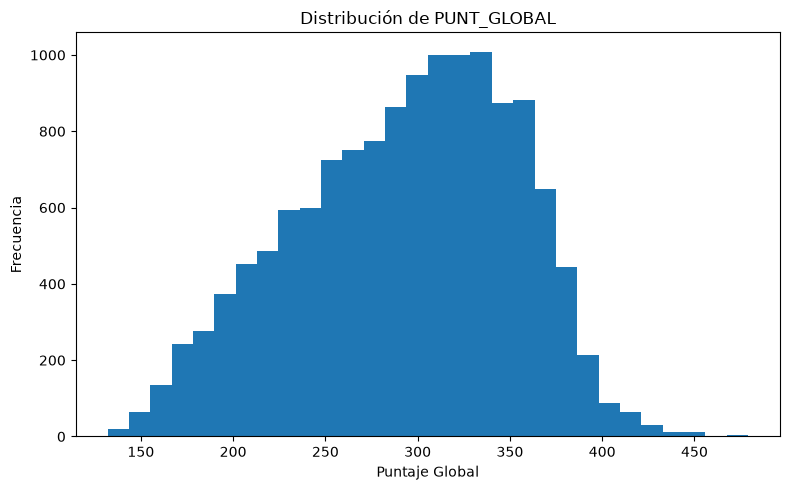

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(model_df[TARGET], bins=30)
plt.xlabel("Puntaje Global")
plt.ylabel("Frecuencia")
plt.title("Distribución de PUNT_GLOBAL")
plt.tight_layout()
plt.show()

### 6.2 Puntaje Global por estrato

,count,mean,median,std
fami_estratovivienda,,,,
Estrato 1,776,236.041237,229.0,54.740828
Estrato 2,2269,257.610842,255.0,54.405393
Estrato 3,3247,277.587927,278.0,52.975100
Estrato 4,2725,308.842936,317.0,53.499800
Estrato 5,2334,321.260497,327.0,49.198417
Estrato 6,2091,326.423721,333.0,46.971011
Sin Estrato,144,267.493056,266.0,70.309804


<Figure size 900x500 with 0 Axes>

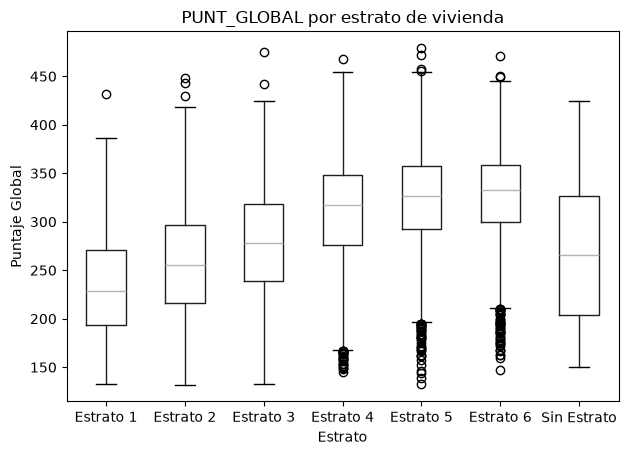

In [26]:
summary_estrato = (
    model_df.groupby("fami_estratovivienda")[TARGET]
    .agg(["count", "mean", "median", "std"])
    .sort_index()
)
display(summary_estrato)

plt.figure(figsize=(9, 5))
model_df.boxplot(column=TARGET, by="fami_estratovivienda", grid=False)
plt.title("PUNT_GLOBAL por estrato de vivienda")
plt.suptitle("")
plt.xlabel("Estrato")
plt.ylabel("Puntaje Global")
plt.tight_layout()
plt.show()

### 6.3 Puntaje Global por personas en el hogar

,count,mean,median,std
fami_personashogar,,,,
1 a 2,1409,282.349184,287.0,61.167002
3 a 4,8528,298.250352,305.0,57.793803
5 a 6,3060,289.838562,296.0,60.152308
7 a 8,453,264.406181,260.0,60.125040
9 o más,136,246.426471,238.0,59.160251


<Figure size 900x500 with 0 Axes>

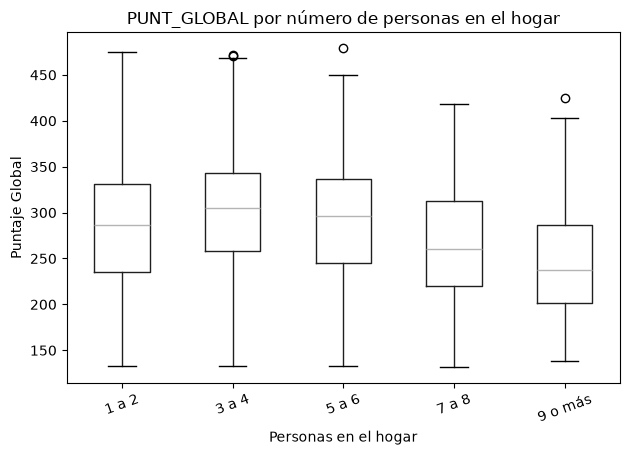

In [27]:
summary_hogar = (
    model_df.groupby("fami_personashogar")[TARGET]
    .agg(["count", "mean", "median", "std"])
)
display(summary_hogar)

plt.figure(figsize=(9, 5))
model_df.boxplot(column=TARGET, by="fami_personashogar", grid=False)
plt.title("PUNT_GLOBAL por número de personas en el hogar")
plt.suptitle("")
plt.xlabel("Personas en el hogar")
plt.ylabel("Puntaje Global")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 6.4 Puntaje Global por género

,count,mean,median,std
estu_genero,,,,
F,6764,291.435837,298.0,58.901303
M,6822,294.669159,301.0,59.951608


<Figure size 700x500 with 0 Axes>

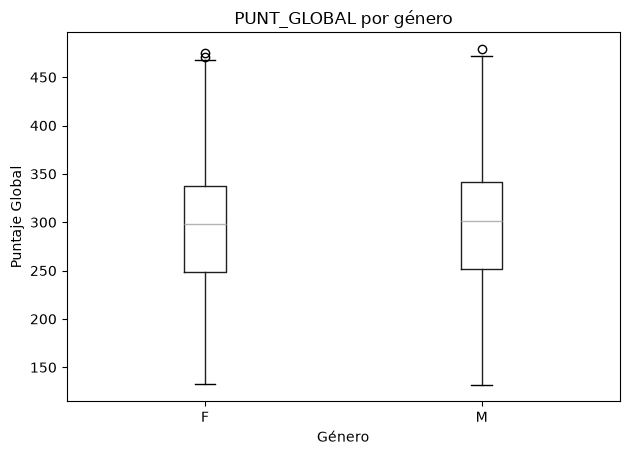

In [28]:
summary_genero = (
    model_df.groupby("estu_genero")[TARGET]
    .agg(["count", "mean", "median", "std"])
)
display(summary_genero)

plt.figure(figsize=(7, 5))
model_df.boxplot(column=TARGET, by="estu_genero", grid=False)
plt.title("PUNT_GLOBAL por género")
plt.suptitle("")
plt.xlabel("Género")
plt.ylabel("Puntaje Global")
plt.tight_layout()
plt.show()

### 6.5 Puntaje Global por naturaleza del colegio

,count,mean,median,std
cole_naturaleza,,,,
NO OFICIAL,13414,294.182645,300.0,58.838878
OFICIAL,172,205.459302,201.0,37.620505


<Figure size 700x500 with 0 Axes>

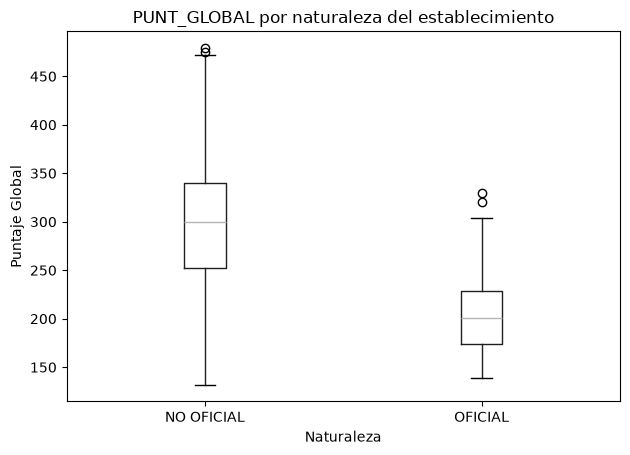

In [29]:
summary_naturaleza = (
    model_df.groupby("cole_naturaleza")[TARGET]
    .agg(["count", "mean", "median", "std"])
)
display(summary_naturaleza)

plt.figure(figsize=(7, 5))
model_df.boxplot(column=TARGET, by="cole_naturaleza", grid=False)
plt.title("PUNT_GLOBAL por naturaleza del establecimiento")
plt.suptitle("")
plt.xlabel("Naturaleza")
plt.ylabel("Puntaje Global")
plt.tight_layout()
plt.show()

## 7. Asociación entre predictores categóricos

Antes de ajustar el modelo se revisa la relación entre las variables independientes mediante Cramér's V. Esto ayuda a identificar asociaciones fuertes entre predictores.

In [30]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.values.sum()
    phi2 = chi2 / n
    r, k = table.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / max(1e-12, min(kcorr - 1, rcorr - 1)))

pairs = []
for i in range(len(FEATURES)):
    for j in range(i + 1, len(FEATURES)):
        pairs.append({
            "Variable 1": FEATURES[i],
            "Variable 2": FEATURES[j],
            "Cramér V": cramers_v(model_df[FEATURES[i]], model_df[FEATURES[j]])
        })

display(pd.DataFrame(pairs))

,Variable 1,Variable 2,Cramér V
0,fami_estratovivienda,fami_personashogar,0.087335
1,fami_estratovivienda,estu_genero,0.038666
2,fami_estratovivienda,cole_naturaleza,0.237901
3,fami_personashogar,estu_genero,0.015656
4,fami_personashogar,cole_naturaleza,0.058783
5,estu_genero,cole_naturaleza,0.009757


## 8. Preparación para el modelo

Todas las variables predictoras se consideran categóricas. Se utiliza `OneHotEncoder` con `drop='first'`, de modo que cada conjunto de categorías tenga una categoría de referencia y se evite la trampa de variables ficticias.

In [31]:
X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), FEATURES)
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (10868, 4)
Prueba: (2718, 4)


## 9. Evaluación predictiva

In [32]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "RMSE", "R²"],
    "Valor": [mae, mse, rmse, r2]
})

display(metrics)

,Métrica,Valor
0,MAE,41.986694
1,MSE,2684.329255
2,RMSE,51.810513
3,R²,0.236262


### 9.1 Valores reales vs. predichos

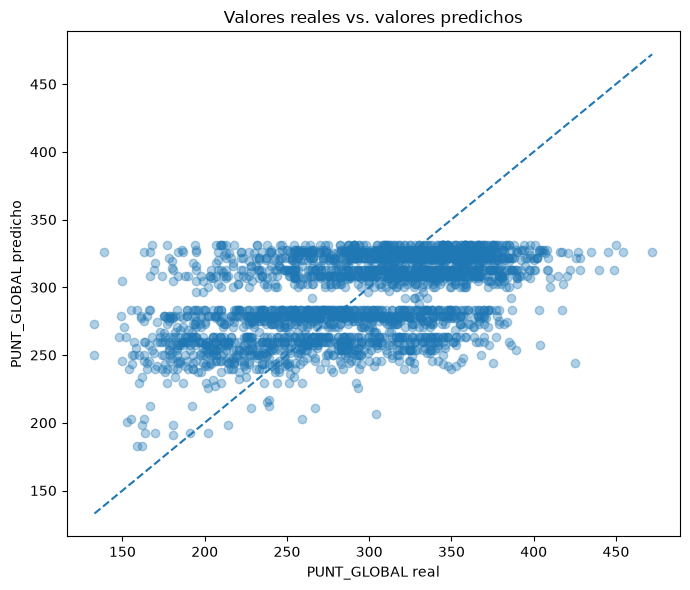

In [33]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.35)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("PUNT_GLOBAL real")
plt.ylabel("PUNT_GLOBAL predicho")
plt.title("Valores reales vs. valores predichos")
plt.tight_layout()
plt.show()

### 9.2 Residuos frente a predicciones

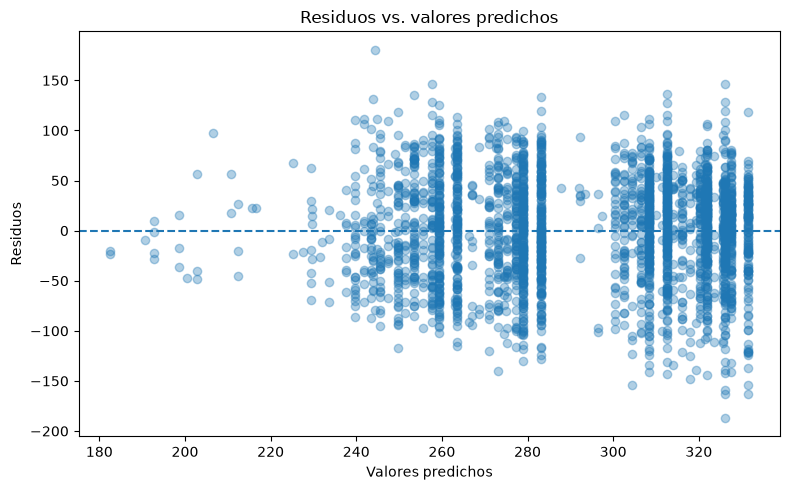

In [34]:
residuals_test = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals_test, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs. valores predichos")
plt.tight_layout()
plt.show()

## 10. Modelo OLS para diagnóstico estadístico

Para complementar la evaluación predictiva se ajusta un modelo OLS con las mismas variables dummy utilizadas en la especificación de la regresión. Esta implementación se realiza con `statsmodels` porque facilita la consulta de coeficientes, intervalos de confianza y pruebas de diagnóstico.

El modelo principal para la predicción y el cálculo de MAE, MSE, RMSE y R² es el pipeline de `scikit-learn`. El modelo OLS se utiliza como herramienta complementaria para analizar la especificación y los supuestos estadísticos.

In [35]:
X_dummies = pd.get_dummies(
    model_df[FEATURES],
    drop_first=True,
    dtype=float
)

X_ols = sm.add_constant(X_dummies)
ols_model = sm.OLS(model_df[TARGET], X_ols).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            punt_global   R-squared:                       0.247
Model:                            OLS   Adj. R-squared:                  0.246
Method:                 Least Squares   F-statistic:                     370.8
Date:                Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:19:56   Log-Likelihood:                -72852.
No. Observations:               13586   AIC:                         1.457e+05
Df Residuals:                   13573   BIC:                         1.458e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

### 10.1 Coeficientes

In [36]:
coef_table = pd.DataFrame({
    "Coeficiente": ols_model.params,
    "p_value": ols_model.pvalues,
    "IC_2.5%": ols_model.conf_int()[0],
    "IC_97.5%": ols_model.conf_int()[1],
})
display(coef_table)

,Coeficiente,p_value,IC_2.5%,IC_97.5%
const,235.842378,0.000000e+00,231.263748,240.421008
fami_estratovivienda_Estrato 2,16.553548,3.159557e-14,12.284069,20.823026
fami_estratovivienda_Estrato 3,35.089181,2.062920e-61,30.950479,39.227883
fami_estratovivienda_Estrato 4,65.355206,3.155456e-195,61.127620,69.582791
fami_estratovivienda_Estrato 5,77.581355,1.728492e-261,73.275669,81.887041
fami_estratovivienda_Estrato 6,83.029318,3.182672e-290,78.667940,87.390696
fami_estratovivienda_Sin Estrato,30.294120,1.082923e-10,21.102026,39.486214
fami_personashogar_3 a 4,8.126954,5.113146e-08,5.204246,11.049662
fami_personashogar_5 a 6,2.686428,1.074884e-01,-0.584864,5.957719
fami_personashogar_7 a 8,-7.984499,4.323561e-03,-13.468253,-2.500745


## 11. Validación de supuestos

La validación se realiza sobre los residuos del modelo OLS. Debido a que los predictores son categóricos, la revisión de la linealidad se interpreta principalmente como una revisión de la forma funcional y de la aditividad de los efectos incluidos. No se pretende comprobar una relación lineal continua entre cada predictor y `punt_global`.

Se revisan:

1. **Linealidad y aditividad:** mediante la inspección de residuos frente a valores ajustados.
2. **Homoscedasticidad:** mediante la prueba de Breusch-Pagan y el gráfico de residuos.
3. **Distribución de los residuos:** mediante histograma y Q-Q plot.
4. **Observaciones potencialmente influyentes:** mediante la distancia de Cook.

Los diagnósticos se interpretan junto con el tamaño de la muestra, ya que con muestras grandes las pruebas estadísticas pueden detectar desviaciones pequeñas de los supuestos.

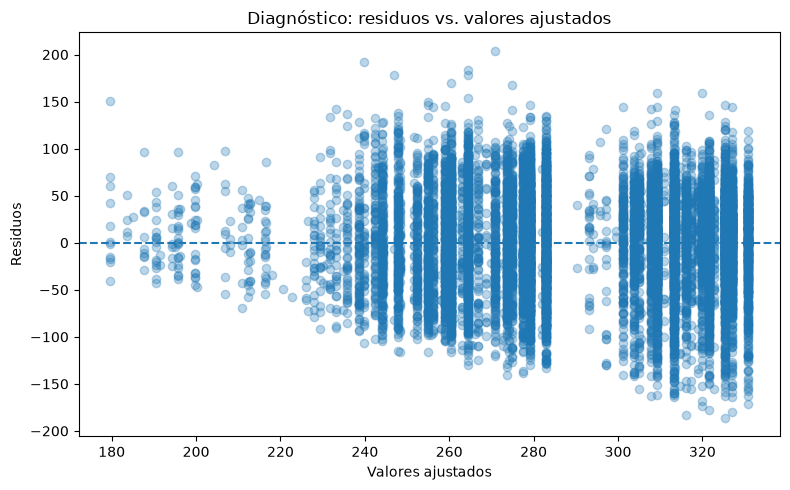

In [37]:
fitted = ols_model.fittedvalues
resid = ols_model.resid

# Residuos vs. valores ajustados
plt.figure(figsize=(8, 5))
plt.scatter(fitted, resid, alpha=0.30)
plt.axhline(0, linestyle="--")
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Diagnóstico: residuos vs. valores ajustados")
plt.tight_layout()
plt.show()

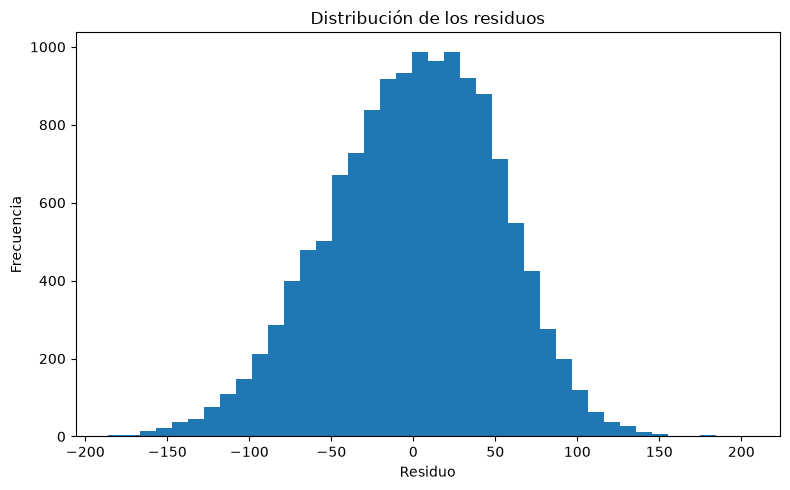

In [38]:
# Histograma de residuos
plt.figure(figsize=(8, 5))
plt.hist(resid, bins=40)
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Distribución de los residuos")
plt.tight_layout()
plt.show()

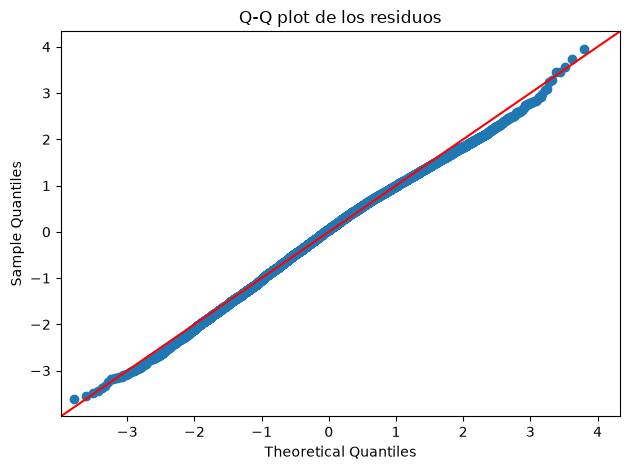

In [39]:
# Q-Q plot
sm.qqplot(resid, line="45", fit=True)
plt.title("Q-Q plot de los residuos")
plt.tight_layout()
plt.show()

In [40]:
# Breusch-Pagan
bp = het_breuschpagan(resid, X_ols)
bp_results = pd.Series(
    bp,
    index=["LM Statistic", "LM p-value", "F Statistic", "F p-value"]
)
display(bp_results.to_frame("Resultado"))

,Resultado
LM Statistic,1.404369e+02
LM p-value,4.888605e-24
F Statistic,1.181399e+01
F p-value,3.617274e-24


### Interpretación del Breusch-Pagan

- **p > 0,05:** no se encuentra evidencia estadística suficiente para rechazar la homoscedasticidad.
- **p ≤ 0,05:** existe evidencia estadística de que la varianza de los residuos no es constante.

El resultado de esta prueba debe complementarse con la inspección gráfica. Una prueba significativa no implica por sí sola que el modelo deje de ser útil para el objetivo predictivo, pero sí constituye una limitación para la inferencia basada en los supuestos clásicos de los errores.

,indice,cooks_distance
11450,11450,0.012926
115,115,0.005308
12990,12990,0.004533
79,79,0.003216
544,544,0.003189
10161,10161,0.002834
126,126,0.002815
10409,10409,0.002732
7394,7394,0.002699
774,774,0.002668


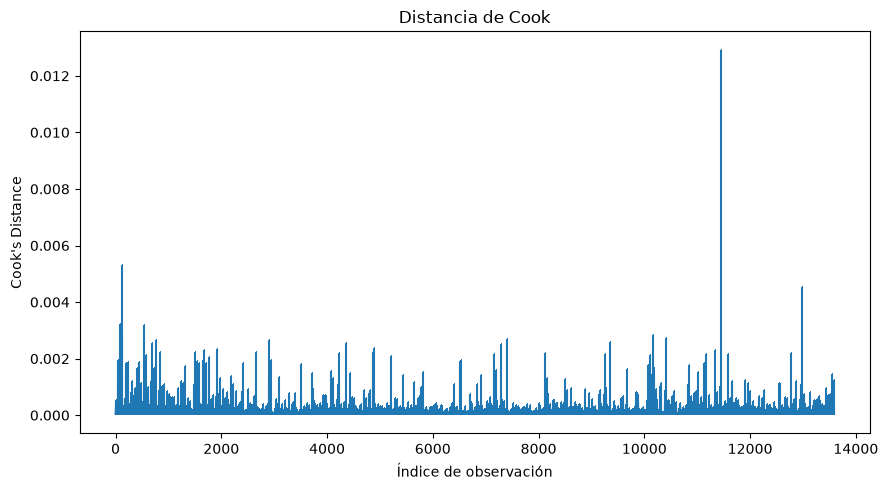

In [41]:
# Cook's Distance
influence = ols_model.get_influence()
cooks_d = influence.cooks_distance[0]

cook_df = pd.DataFrame({
    "indice": np.arange(len(cooks_d)),
    "cooks_distance": cooks_d
}).sort_values("cooks_distance", ascending=False)

display(cook_df.head(10))

plt.figure(figsize=(9, 5))
plt.stem(cooks_d, markerfmt=",", basefmt=" ")
plt.xlabel("Índice de observación")
plt.ylabel("Cook's Distance")
plt.title("Distancia de Cook")
plt.tight_layout()
plt.show()

## 12. Multicolinealidad

Se calcula VIF sobre las variables dummy utilizadas por el modelo OLS. Valores altos pueden indicar redundancia entre predictores.

In [42]:
vif = pd.DataFrame({
    "Variable": X_ols.columns,
    "VIF": [
        variance_inflation_factor(X_ols.values, i)
        for i in range(X_ols.shape[1])
    ]
})

display(vif.sort_values("VIF", ascending=False))

,Variable,VIF
2,fami_estratovivienda_Estrato 3,4.135002
3,fami_estratovivienda_Estrato 4,3.803713
4,fami_estratovivienda_Estrato 5,3.501079
1,fami_estratovivienda_Estrato 2,3.365907
5,fami_estratovivienda_Estrato 6,3.287737
7,fami_personashogar_3 a 4,2.649620
8,fami_personashogar_5 a 6,2.478620
9,fami_personashogar_7 a 8,1.286485
6,fami_estratovivienda_Sin Estrato,1.176093
10,fami_personashogar_9 o más,1.091097


## 13. Conclusiones del análisis

El modelo de Regresión Lineal permite estimar el `punt_global` utilizando cuatro características categóricas relacionadas con el contexto familiar, sociodemográfico y educativo del estudiante.

En el conjunto de prueba se obtuvo un **MAE de aproximadamente 41,99 puntos**, un **RMSE de aproximadamente 51,81 puntos** y un **R² de aproximadamente 0,2363**. Por tanto, las variables seleccionadas contienen información útil para la predicción, pero explican una parte limitada de la variabilidad del Puntaje Global.

El análisis descriptivo muestra diferencias entre las categorías de los predictores, especialmente en el estrato de vivienda y en la naturaleza del establecimiento. Estas diferencias deben interpretarse como **asociaciones**, no como efectos causales.

Entre las principales limitaciones se encuentran la eliminación de registros con valores faltantes, la representación desigual de algunas categorías, la posible existencia de variables omitidas y la evidencia de heterocedasticidad y desviaciones de la normalidad de los residuos.

Como trabajo futuro podría evaluarse un modelo ampliado con otras variables disponibles en el conjunto de datos y comparar la regresión lineal con modelos capaces de representar relaciones no lineales e interacciones entre características.

## 14. Reproducibilidad

Para ejecutar el proyecto:

```bash
pip install -r ../requirements.txt
```

Luego abrir este notebook con Jupyter/VS Code/Google Colab.

La fuente de datos es:

https://www.datos.gov.co/en/en/Education/Saber-11-2020-1/a8xr-en99

API:

https://www.datos.gov.co/resource/a8xr-en99.json